In [1]:
from google import genai
from PIL import Image
from dotenv import load_dotenv

import os
import json

In [2]:
load_dotenv()

client = genai.Client(
    api_key=os.getenv("GEMINI_API_KEY")
)

In [3]:
client

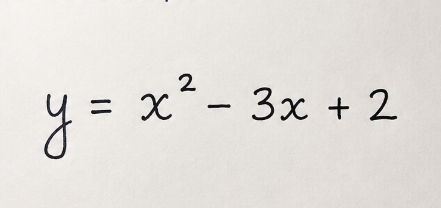

In [4]:
image = Image.open("../images/qudratic.png")

image

In [31]:
prompt = r"""
You are an OCR engine specialised in mathematical equations.

Extract the primary equation from the image.

Return ONLY valid JSON.

Schema:

{
  "equation": "",
  "sympy": "",
  "latex": "",
  "variable": "",
  "graphable": true
}

Rules:

1. "equation" should preserve normal mathematical notation.
2. "sympy" MUST be directly compatible with sympy.sympify().
3. Use ** for powers.
4. Use explicit multiplication (3*x, x*sin(x), 2*pi*x).
5. Use SymPy function names:
   - sin
   - cos
   - tan
   - asin
   - acos
   - atan
   - log
   - exp
   - sqrt
   - Abs
6. Use constants:
   - pi
   - E
7. Do not include "y =" in the sympy field.
8. Return valid JSON only.
9. If the equation cannot be graphed as y=f(x), set graphable to false.

Importent:
- "latex" MUST be valid LaTeX math.
- Use ^{...} for exponents.
- Use \frac{}{} for fractions.
- Use \sqrt{} for square roots.
- Use \sin, \cos, \tan, \log, \exp.
- Do not wrap the LaTeX with $$ or \( \).
- Do not include markdown.
- "sympy" must be directly compatible with sympy.sympify().
- No markdown
- No explanation
- No comments
- If multiple equations exist, choose the main one.
- If not graphable, set graphable to false.
"""

In [34]:
prompt = r"""
You are a mathematical OCR engine.

Extract the main mathematical equation from the image and return ONLY a valid JSON object.

Schema:
{
  "equation": "human-readable equation",
  "sympy": "expression compatible with sympy.sympify()",
  "variable": "main variable",
  "graphable": true
}

Rules:
- Return raw JSON only. Do NOT wrap it in ``` or markdown.
- The "sympy" field must use:
  - ** for powers
  - explicit multiplication (3*x, 2*pi*x, x*sin(x))
  - SymPy functions: sin, cos, tan, asin, acos, atan, log, exp, sqrt, Abs
  - constants: pi, E
- Exclude "y =" (or similar) from the "sympy" field.
- If the equation is not a single graphable function of one variable, set "graphable" to false.
"""

In [36]:
from google.genai import types

In [37]:
response = client.models.generate_content(
    model="gemini-2.5-flash",
    contents=[prompt, image],
    config=types.GenerateContentConfig(
        response_mime_type="application/json"
    )
)

print(response.text)

{
  "equation": "y = x^2 - 3x + 2",
  "sympy": "x**2 - 3*x + 2",
  "variable": "x",
  "graphable": true
}


In [38]:
result = json.loads(response.text)

result

{'equation': 'y = x^2 - 3x + 2',
 'sympy': 'x**2 - 3*x + 2',
 'variable': 'x',
 'graphable': True}

In [20]:
print(result["equation"])
print(result["latex"])
print(result["graphable"])

y = x^2 - 3x + 2
y = x^2 - 3x + 2
True


In [9]:
import numpy as np
import plotly.graph_objects as go
from sympy import symbols, sympify, lambdify, simplify

In [10]:
x = symbols("x")


In [21]:
expr = sympify(result["sympy"])
expr

x**2 - 3*x + 2

In [22]:
f = lambdify(x, expr, "numpy")

In [23]:
import numpy as np

x_values = np.linspace(-10, 10, 1000)

y_values = f(x_values)

In [41]:
from sympy import sympify, latex

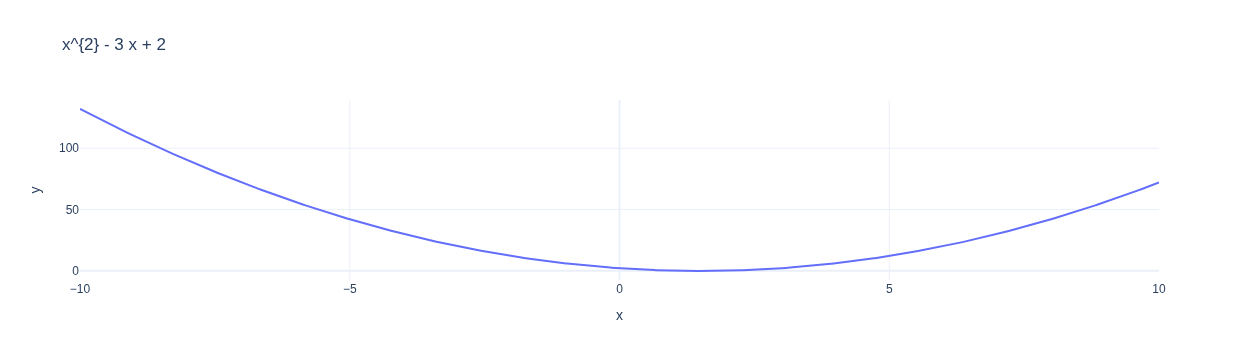

In [42]:
import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=x_values,
        y=y_values,
        mode="lines",
        name="f(x)"
    )
)

fig.update_layout(
    title=latex(expr),
    xaxis_title="x",
    yaxis_title="y",
    template="plotly_white",
    hovermode="closest"
)

fig.show()

In [25]:
import numpy as np
import plotly.graph_objects as go

from sympy import symbols, sympify, lambdify


def plot_equation(sympy_expression: str, variable: str = "x"):
    var = symbols(variable)

    expr = sympify(sympy_expression)

    func = lambdify(var, expr, "numpy")

    x_values = np.linspace(-10, 10, 1000)
    y_values = func(x_values)

    fig = go.Figure()

    fig.add_trace(
        go.Scatter(
            x=x_values,
            y=y_values,
            mode="lines",
            line=dict(width=3),
            name="f(x)"
        )
    )

    fig.update_layout(
        template="plotly_white",
        hovermode="closest",
        dragmode="pan",
        title=sympy_expression,
        xaxis_title=variable,
        yaxis_title="y"
    )

    fig.show()

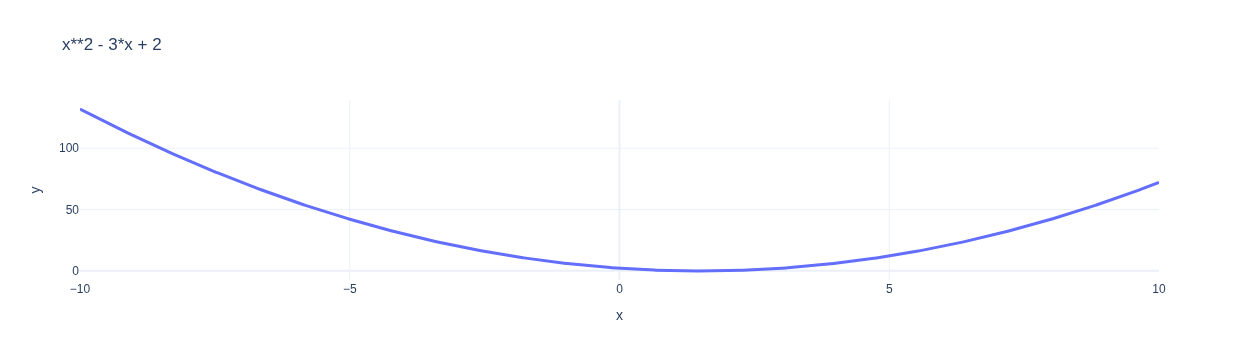

In [26]:
plot_equation(result["sympy"])

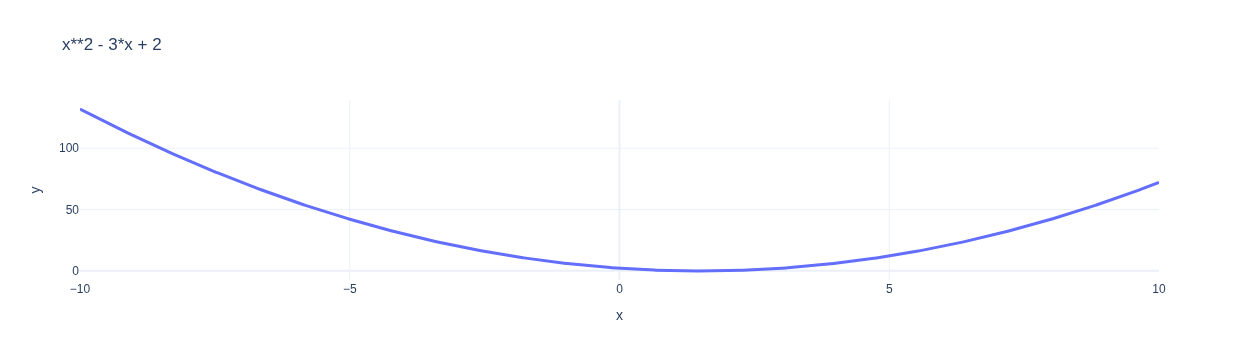

In [27]:
plot_equation(
    result["sympy"],
    result["variable"]
)